In [2]:
from pathlib import Path
import numpy as np
import suite2p
import mbo_utilities as mbo
import lbm_suite2p_python as lsp

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


In [17]:
raw_files = mbo.get_files(r"D:\W2_DATA\wsnyder\2025_03_06\raw\dot_lv6", "tif")
scan = mbo.read_scan(raw_files)

In [18]:
mbo.save_as(scan, "D://demo_anatomical//assembled", target_chunk_mb=100)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/56 [00:00<?, ?it/s]

Time elapsed: 0 minutes 17 seconds.


In [19]:
assembled_files = mbo.get_files("D://demo_anatomical//assembled", 'tif')
assembled_files

['D:\\demo_anatomical\\assembled\\plane_01.tif',
 'D:\\demo_anatomical\\assembled\\plane_02.tif',
 'D:\\demo_anatomical\\assembled\\plane_03.tif',
 'D:\\demo_anatomical\\assembled\\plane_04.tif',
 'D:\\demo_anatomical\\assembled\\plane_05.tif',
 'D:\\demo_anatomical\\assembled\\plane_06.tif',
 'D:\\demo_anatomical\\assembled\\plane_07.tif',
 'D:\\demo_anatomical\\assembled\\plane_08.tif',
 'D:\\demo_anatomical\\assembled\\plane_09.tif',
 'D:\\demo_anatomical\\assembled\\plane_10.tif',
 'D:\\demo_anatomical\\assembled\\plane_11.tif',
 'D:\\demo_anatomical\\assembled\\plane_12.tif',
 'D:\\demo_anatomical\\assembled\\plane_13.tif',
 'D:\\demo_anatomical\\assembled\\plane_14.tif']

In [ ]:
iw = mbo.run_gui(assembled_files[7])
iw.show()

In [22]:
iw.close()

In [56]:
demo_file = assembled_files[6]
metadata = mbo.get_metadata(demo_file)
base_ops = mbo.params_from_metadata(metadata, suite2p.default_ops())

demo_file, ops["anatomical_only"], ops["tau"], ops["threshold_scaling"]

Ops provided. Setting pipeline to suite2p


('D:\\demo_anatomical\\assembled\\plane_07.tif', 3, 0.15, 1.0)

In [28]:
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 3
ops["cellprob_thresh"] = 3
ops["diameter"] = 7
ops["spatial_hp_cp"] = 1

D:\demo_anatomical\assembled\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
{'registration': 21.936908721923828, 'detection': 5.8625617027282715, 'extraction': 0.6053845882415771, 'classification': 0.019999265670776367, 'deconvolution': 0.015508651733398438, 'total_plane_runtime': 28.45737934112549}


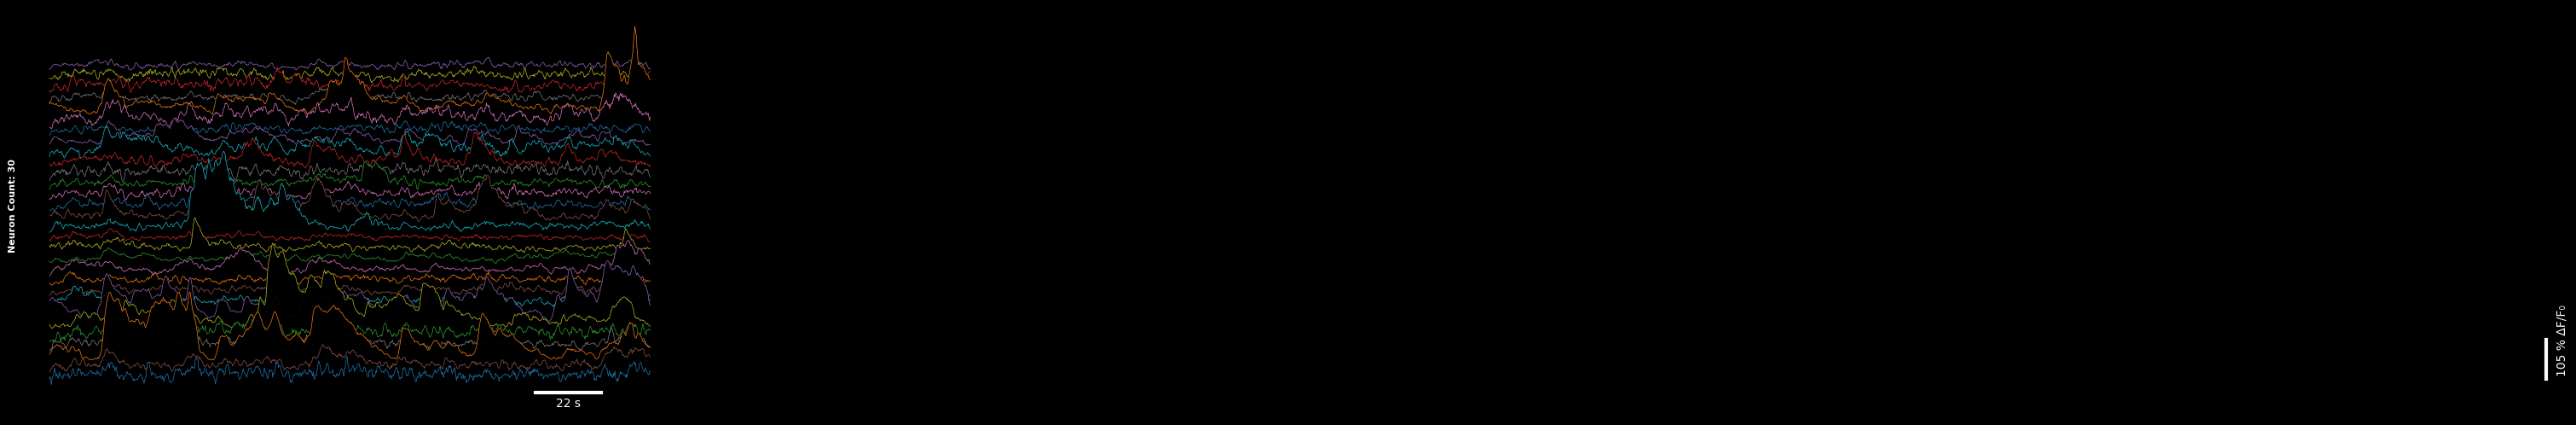

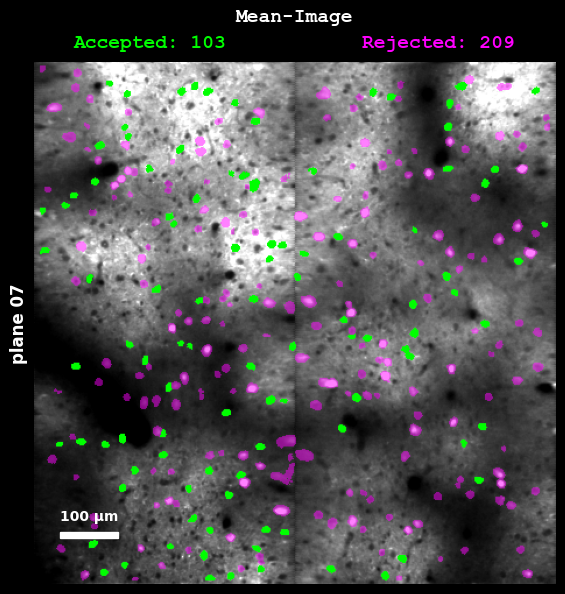

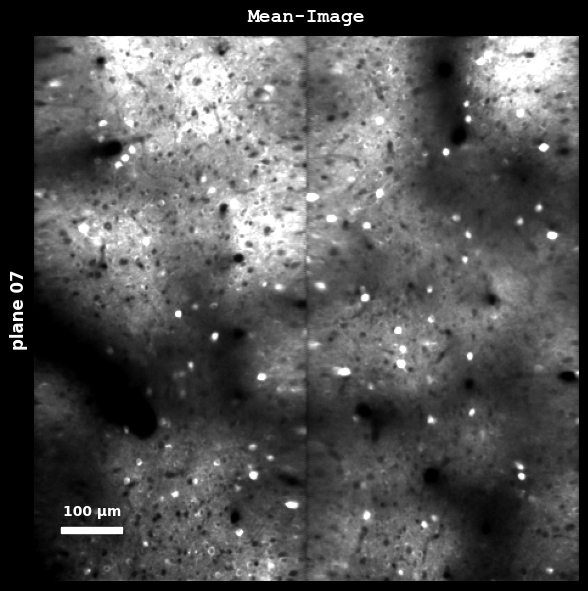

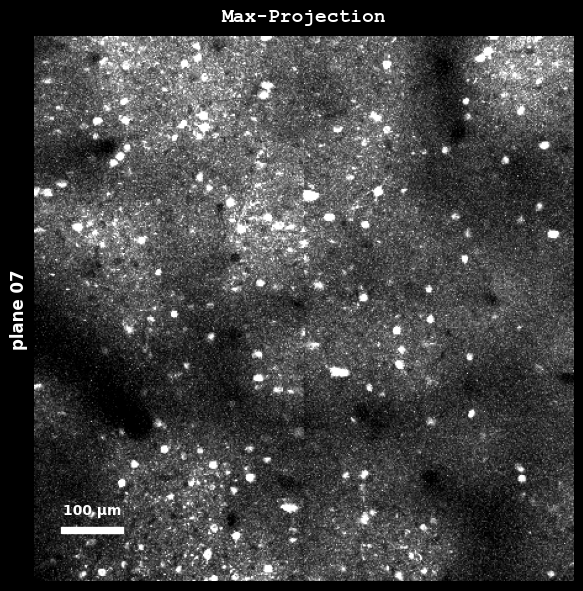

In [30]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_anatomical//results", save_folder=None)

In [ ]:
import os
os.mkdir("D://demo_anatomical//results//figures")

In [55]:
f, fneu, spks = lsp.load_traces(output_ops)

In [42]:
def load_results(ops, valid_only:bool=False):
    """
    Load F, Fneu, spks, stat, iscell and cellprob arrays from an ops file.

    Parameters
    ----------
    ops : dict
        Dictionary containing at least the key 'save_path', which specifies the directory where the following
        files are stored: 'F.npy', 'Fneu.npy', 'spks.npy', 'iscell.npy', 'stat.npy'.
    valid_only : bool, optional
        Whether to filter traces by iscell, returning only valid / accepted neurons.

    Returns
    -------
    F: ndarray
        Array of fluorescence traces (n_neurons x n_timepoints).
    Fneu : ndarray
        Array of neuropil fluorescence traces (n_neurons x n_timepoints).
    spks : ndarray
        Array of deconvolved spike estimates (n_neurons x n_timepoints).

    """
    ops = lsp.load_ops(ops)
    
    save_path = Path(ops['save_path'])
    F = np.load(save_path.joinpath('F.npy'))
    Fneu = np.load(save_path.joinpath('Fneu.npy'))
    spks = np.load(save_path.joinpath('spks.npy'))
    stats = np.load(save_path.joinpath('stat.npy'), allow_pickle=True)
    iscell = np.load(save_path.joinpath('iscell.npy'), allow_pickle=True)[:, 0].astype(bool)
    cellprob = np.load(save_path.joinpath('iscell.npy'), allow_pickle=True)[:, 1]

    if valid_only:
        F = F[iscell]
        Fneu = Fneu[iscell]
        spks = spks[iscell]
        stats = stats[iscell]
        cellprob = cellprob[iscell]
    return F, Fneu, spks, stats, iscell, cellprob

In [49]:
f, fneu, spks, stats, iscell, cellprob = load_results(output_ops)
f.shape == fneu.shape == spks.shape

True

In [54]:
stats[0]["skew"]

0.18128827

D:\demo_anatomical\assembled\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
{'registration': 21.936908721923828, 'detection': 5.8625617027282715, 'extraction': 0.6053845882415771, 'classification': 0.019999265670776367, 'deconvolution': 0.015508651733398438, 'total_plane_runtime': 28.45737934112549}


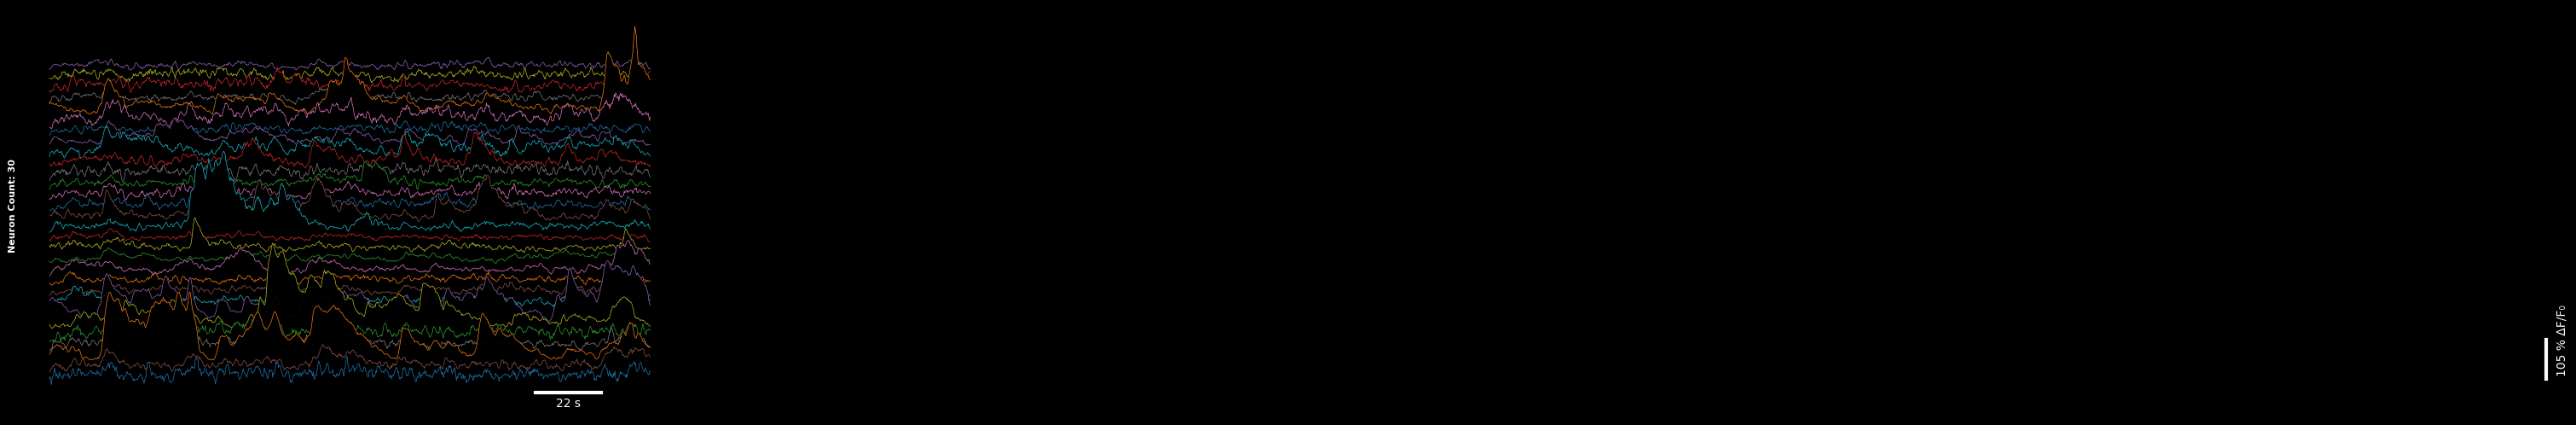

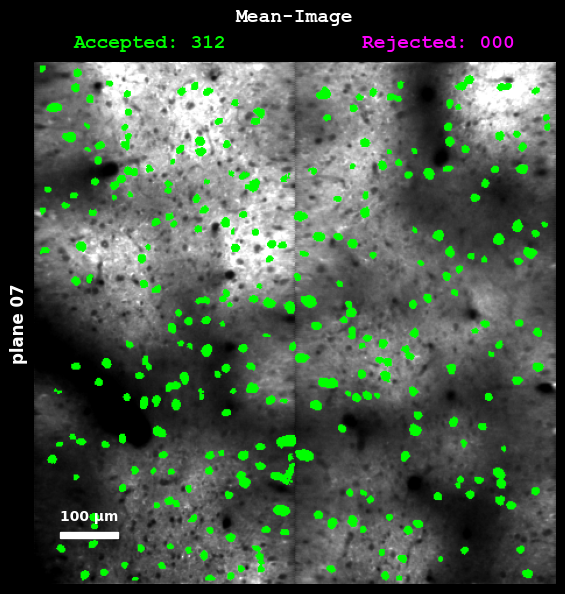

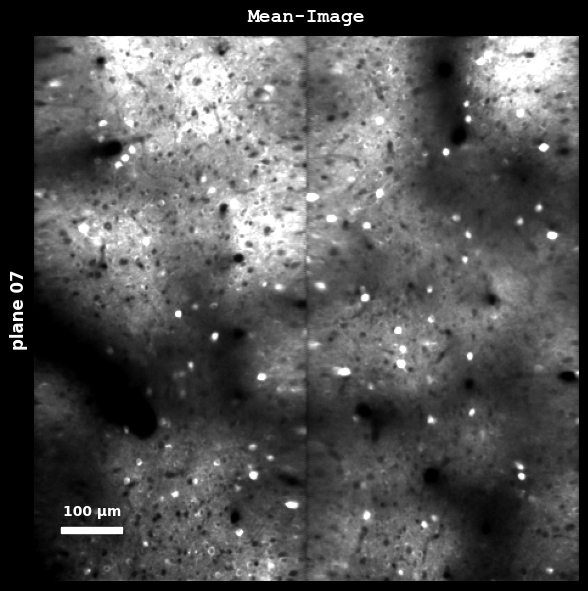

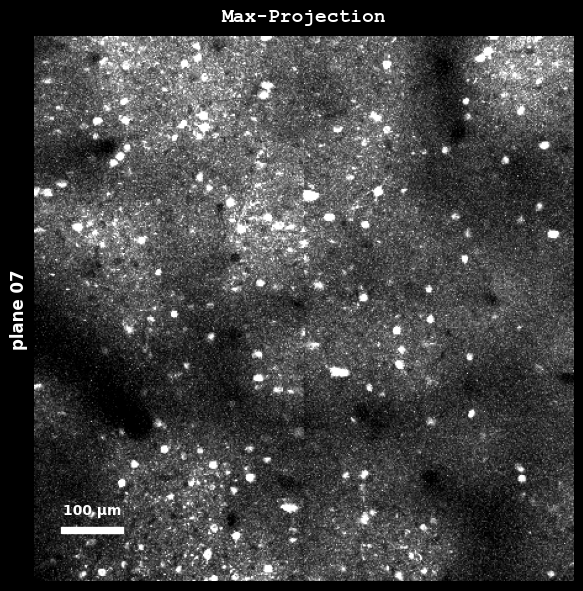

In [59]:
ops["tau"] = 0.15
ops["max_overlap"] = 1.0
ops["anatomical_only"] = 3
ops["cellprob_thresh"] = -6
ops["diameter"] = 7
ops["spatial_hp_cp"] = 1

output_ops = lsp.run_plane(ops, demo_file, "D://demo_anatomical//results", save_folder=None, overwrite=True)

In [ ]:
gs = {spatial_hp_cp}
lsp.run_grid_search(ops, {}